# BioCAS 2023 — Preprocessing Pipeline

Notebook de research para explorar y ejecutar la pipeline de preprocesamiento.

**Flujo:**
1. Cargar config
2. (Opcional) modificar parámetros para experimentar
3. Correr pipeline → obtener `BioCASDataset`
4. Inspeccionar resultados
5. Conectar al training loop

In [7]:
%load_ext autoreload
%autoreload 2

import sys
# sys.path.insert(0, "..")   # ajustar si el notebook está en un subdirectorio

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from pathlib import Path

from pipeline_api import load_config, patch_config, show_config, run_pipeline, load_dataset, save_dataset

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 · Cargar configuración

In [8]:
# Config por defecto (lee config/pipeline.yaml)
cfg = load_config()
show_config(cfg)

data:
  raw_wav_dir: C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\raw_data\train\wav
  raw_json_dir: C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\raw_data\train\json
  test_wav_dir: C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\raw_data\test\wav
  test_json_dir: C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\raw_data\test\json
  output_dir: C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\processed
  task: 1-2
  test: false
stages:
  loading:
    enabled: true
  resampling:
    enabled: true
  event_extraction:
    enabled: true
  balanced_sampling:
    enabled: true
  concatenation:
    enabled: true
  padding:
    enabled: true
  augmentation:
    enabled: true
  log_mel:
    enabled: true
  spec_augment:
    enabled: true
  normalization:
    enabled: true
loading:
  target_sr: 4000
  keep_poor_quality: false
event_extraction:
  min_duration_s: 0.02
  keep_unlabelled

## 2 · Correr la pipeline completa

In [9]:
import torch
import torchaudio

print(f"Torch version: {torch.__version__}")
print(f"Audio version: {torchaudio.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

Torch version: 2.11.0+cu126
Audio version: 2.11.0+cu126
CUDA disponible: True


In [10]:
# run_pipeline() = build + run + wrap en BioCASDataset
dataset = run_pipeline(cfg)
print(dataset)

PreprocessingPipeline
  Device      : cuda (NVIDIA GeForce RTX 3060 Ti)
  Chunk size  : 256
  Task        : 1-2
  Target SR   : 4000 Hz
  Duration    : 8.0s
  Mel bins    : 64

  Fase 1 — sin audio (CPU)
    Loading(lazy) → EventExtraction → BalancedSampling
    Sampling    : sqrt

  Fase 2 — chunks con GPU
    WavLoad → Slice → Resample → Concat → Pad
    → WavAug → LogMel → SpecAugment → Norm
    Augment     : shift=True noise=True stretch=True
    SpecAugment : True
    Normalize   : instance

── Fase 1: Metadata (sin audio) ──────────────────────────


  loading:   0%|          | 0/5258 [00:00<?, ?file/s]

KeyboardInterrupt: 

In [ ]:
cfg_test = load_config(overrides=[
    "data.test=true",
    "stages.balanced_sampling.enabled=false",
    "stages.augmentation.enabled=false",
    "stages.spec_augment.enabled=false",
])

In [ ]:
# run_pipeline() = build + run + wrap en BioCASDataset
test_dataset = run_pipeline(cfg_test)
print(test_dataset)

PreprocessingPipeline
  Device      : cuda (NVIDIA GeForce RTX 3060 Ti)
  Chunk size  : 256
  Task        : 1-2
  Target SR   : 4000 Hz
  Duration    : 8.0s
  Mel bins    : 64

  Fase 1 — sin audio (CPU)
    Loading(lazy) → EventExtraction → BalancedSampling
    Sampling    : sqrt

  Fase 2 — chunks con GPU
    WavLoad → Slice → Resample → Concat → Pad
    → WavAug → LogMel → SpecAugment → Norm
    Augment     : shift=True noise=True stretch=True
    SpecAugment : True
    Normalize   : instance

── Fase 1: Metadata (sin audio) ──────────────────────────


  loading:   0%|          | 0/1309 [00:00<?, ?file/s]

  Recordings: 1,309


  extracting events:   0%|          | 0/1309 [00:00<?, ?recording/s]

  Events:     4,706  (valid labels: 4,706)
  Balanced:   4,706  {'CC': 65, 'FC': 1885, 'N': 2175, 'R': 7, 'S': 8, 'W': 305, 'WC': 261}

── Fase 2: Procesamiento en 19 chunks de 256 ──


...

  concatenation:   0%|          | 0/98 [00:00<?, ?sample/s]

  padding:   0%|          | 0/98 [00:00<?, ?sample/s]

  log-mel:   0%|          | 0/98 [00:00<?, ?sample/s]

  normalizing:   0%|          | 0/98 [00:00<?, ?sample/s]


── Done: 4,706 samples en 48.4s ──
✓ Dataset guardado en 'C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\processed\test'
BioCASDataset(n=4706, n_classes=7, feature_shape=(1, 64, 251), mode=in-memory)


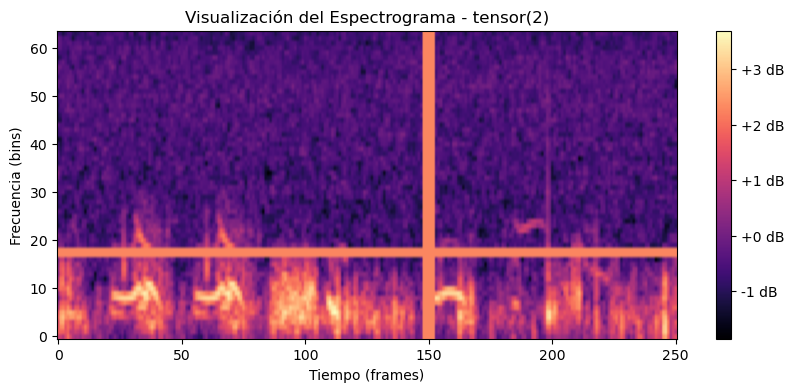

In [ ]:
import matplotlib.pyplot as plt

sample, label = dataset.__getitem__(1000)


sample_np = sample.squeeze().detach().cpu().numpy()

plt.figure(figsize=(10, 4))
# origin='lower' para que las frecuencias bajas queden abajo
plt.imshow(sample_np, aspect='auto', origin='lower', cmap='magma')

plt.title('Visualización del Espectrograma - ' + str(label))
plt.xlabel('Tiempo (frames)')
plt.ylabel('Frecuencia (bins)')
plt.colorbar(format='%+2.0f dB')
plt.show()

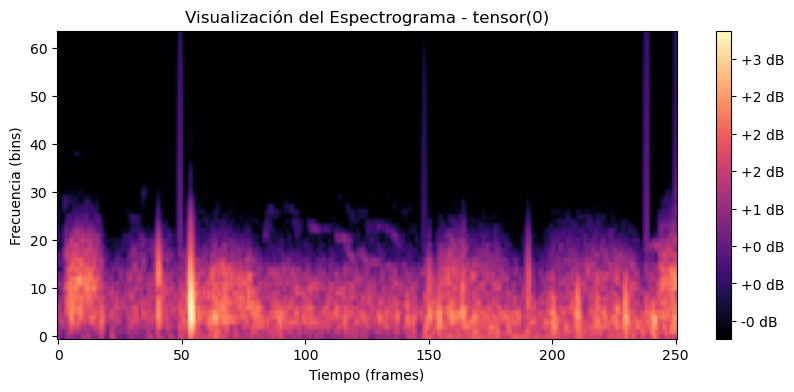

In [ ]:
import matplotlib.pyplot as plt

sample, label = test_dataset.__getitem__(1000)


sample_np = sample.squeeze().detach().cpu().numpy()

plt.figure(figsize=(10, 4))
# origin='lower' para que las frecuencias bajas queden abajo
plt.imshow(sample_np, aspect='auto', origin='lower', cmap='magma')

plt.title('Visualización del Espectrograma - ' + str(label))
plt.xlabel('Tiempo (frames)')
plt.ylabel('Frecuencia (bins)')
plt.colorbar(format='%+2.0f dB')
plt.show()

# Training loop
---

In [1]:
%load_ext autoreload
%autoreload 2


import sys
sys.path.insert(0, "..")  

#import models.networks   # registra EfficientNet, ResNet en MODEL_REGISTRY
import models.cnns   # registra EfficientNet, ResNet en MODEL_REGISTRY
from models.base import MODEL_REGISTRY
from pipeline_api import load_dataset
from train import objective, resolve_device, parse_args
import optuna
import argparse
from pipeline_api import load_dataset
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\camsp\_netrc.
wandb: Currently logged in as: czambrano to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [10]:
test_dataset = load_dataset("../data/processed/test")
train_dataset = load_dataset("../data/processed/train")

print(train_dataset)
print(test_dataset)
print("Modelos disponibles:", list(MODEL_REGISTRY.keys()))

✓ Dataset cargado desde '..\data\processed\test'
  BioCASDataset(n=4706, n_classes=7, feature_shape=(1, 64, 251), mode=lazy (per-file))
✓ Dataset cargado desde '..\data\processed\train'
  BioCASDataset(n=19872, n_classes=7, feature_shape=(1, 64, 251), mode=lazy (per-file))
BioCASDataset(n=19872, n_classes=7, feature_shape=(1, 64, 251), mode=lazy (per-file))
BioCASDataset(n=4706, n_classes=7, feature_shape=(1, 64, 251), mode=lazy (per-file))
Modelos disponibles: ['custom_cnn', 'efficientnet_b0', 'resnet18']


In [3]:
# sin optuna

args = argparse.Namespace(
    n_epochs        = 30,
    num_workers     = 0,       # siempre 0 en notebook
    device          = "auto",
    seed            = 42,
    wandb_project   = "biocas",
    wandb_entity    = "tu-equipo",
    wandb_group     = "nas-v1",
    log_image_every = 30,      # solo al final de cada trial
)
#best_acc = objective(None, train_dataset, test_dataset, args)
#print(f"Val acc: {best_acc:.2f}%")

In [ ]:
# ── 4a. Probar un modelo concreto antes de lanzar la búsqueda ─────────────
# Útil para verificar que el forward pass no explota con tus datos reales
import optuna
from models.cnns import CustomAudioCNN

trial = optuna.trial.FixedTrial({
    "n_blocks"      : 3,
    "base_channels" : 32,
    "channel_growth": "double",
    "kernel_size"   : 3,
    "norm"          : "batch",
    "activation"    : "relu",
    "pool_type"     : "max",
    "use_se"        : False,
    "use_residual"  : True,
    "global_pool"   : "avg",
    "dropout"       : 0.2,
})
model = CustomAudioCNN.build(trial, num_classes=train_dataset.num_classes)
print(model)
print(f"Parámetros: {model.n_parameters():,}")

CustomAudioCNN(name='custom_cnn', params=112,327)
Parámetros: 112,327


In [ ]:
# ── 4b. Búsqueda NAS completa ─────────────────────────────────────────────
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
study  = optuna.create_study(
    study_name = "biocas-nas",
    direction  = "maximize",
    pruner     = pruner,
)

study.optimize(
    lambda trial, _: objective(trial, train_dataset, test_dataset, args),
    n_trials          = 20,
    show_progress_bar = True,
)

[I 2026-07-27 23:03:51,955] A new study created in memory with name: biocas-nas


  0%|          | 0/20 [00:00<?, ?it/s]

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   1/30 | train_loss=0.8082 train_acc=70.57% | val_loss=10.3595 val_acc=46.09%


Epoch   2/30 | train_loss=0.2446 train_acc=89.74% | val_loss=3.6150 val_acc=44.79%


...

Epoch   7/30 | train_loss=1.0056 train_acc=50.44% | val_loss=1.5286 val_acc=35.36%


Epoch   8/30 | train_loss=0.9768 train_acc=51.66% | val_loss=1.5363 val_acc=37.59%


Epoch   9/30 | train_loss=0.9166 train_acc=54.40% | val_loss=1.4355 val_acc=41.63%


epoch,▁▂▃▃▄▅▆▆▇█
lr,██▇▇▆▅▄▃▂▁
train/acc,▁▄▅▆▆▇▇▇██
train/loss,█▅▄▃▃▂▂▂▁▁
val/acc,▇█▁▂▇█▇▇█▄
val/loss,▅▂█▆▂▁▂▂▁▆
epoch,10
lr,0.00047
train/acc,54.50886
train/loss,0.89827
val/acc,22.67318


[I 2026-07-28 13:24:50,446] Trial 19 pruned. 


## Results

In [26]:
import joblib

study = joblib.load("optuna_study.pkl")

In [27]:
# ── 5. Analizar resultados ────────────────────────────────────────────────
print("Mejor arquitectura encontrada:")
for k, v in study.best_trial.params.items():
    print(f"  {k:<20} {v}")

# Qué parámetros importaron más
optuna.visualization.plot_param_importances(study).show()

# Historia de la búsqueda
optuna.visualization.plot_optimization_history(study).show()

# Relación entre pares de hiperparámetros y val_acc
#optuna.visualization.plot_contour(study, params=["n_blocks", "base_channels"]).show()

Mejor arquitectura encontrada:
  model                resnet18
  lr                   0.0012186213573219052
  weight_decay         0.00010548600141434184
  batch_size           512
  dropout              0.30466657713647255


In [29]:
# ── 6. Reconstruir y guardar el mejor modelo ──────────────────────────────
import torch
from models.cnns import CustomAudioCNN
from models.networks import ResNet18Classifier

best_trial = optuna.trial.FixedTrial(study.best_trial.params)
best_model = ResNet18Classifier.build(best_trial, num_classes=train_dataset.num_classes)
best_model = best_model.to(resolve_device(args.device))

torch.save({
    "params"     : study.best_trial.params,
    "state_dict" : best_model.state_dict(),
    "num_classes": train_dataset.num_classes,
    "val_acc"    : study.best_trial.value,
}, "best_model.pt")

print(f"Guardado | val_acc={study.best_trial.value:.2f}%")

Guardado | val_acc=63.83%


In [38]:
fixed_trial = optuna.trial.FixedTrial(study.best_trial.params)
best_val_acc, model = objective(fixed_trial, train_dataset, test_dataset, args)

Epoch   1/30 | train_loss=0.8041 train_acc=70.12% | val_loss=10.1014 val_acc=46.15%


Epoch   2/30 | train_loss=0.2471 train_acc=90.01% | val_loss=3.1543 val_acc=49.41%


Epoch   3/30 | train_loss=0.1252 train_acc=93.79% | val_loss=3.9663 val_acc=49.58%


Epoch   4/30 | train_loss=0.0795 train_acc=95.68% | val_loss=5.5604 val_acc=51.15%


Epoch   5/30 | train_loss=0.0660 train_acc=96.59% | val_loss=3.5912 val_acc=56.35%


...

Epoch  27/30 | train_loss=0.0002 train_acc=100.00% | val_loss=5.8587 val_acc=58.01%


Epoch  28/30 | train_loss=0.0002 train_acc=100.00% | val_loss=6.0218 val_acc=56.99%


Epoch  29/30 | train_loss=0.0002 train_acc=100.00% | val_loss=5.8693 val_acc=57.48%


Epoch  30/30 | train_loss=0.0001 train_acc=100.00% | val_loss=5.9271 val_acc=57.35%


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇████
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
train/acc,▁▆▇▇▇▇████████████████████████
train/loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▃▄▆▇▇▆█▅▆▅▅▄▇▇▆▇▇▆▇▇▇▇▇▇▇▆▇▇
val/loss,█▁▂▃▁▁▂▂▂▃▃▃▄▅▃▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄
epoch,30
lr,0
train/acc,100
train/loss,0.00015
val/acc,57.35232


In [39]:
model.eval()

ResNet18Classifier(name='resnet18', params=11,173,831)

In [43]:
from torch.utils.data import DataLoader
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)


all_preds  = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(resolve_device(args.device))
        logits   = model(features)
        preds    = torch.argmax(logits, dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print(f"Total muestras evaluadas: {len(all_labels)}")

Total muestras evaluadas: 4706


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

In [45]:
accuracy_score(all_labels, all_preds)

0.573523161920952

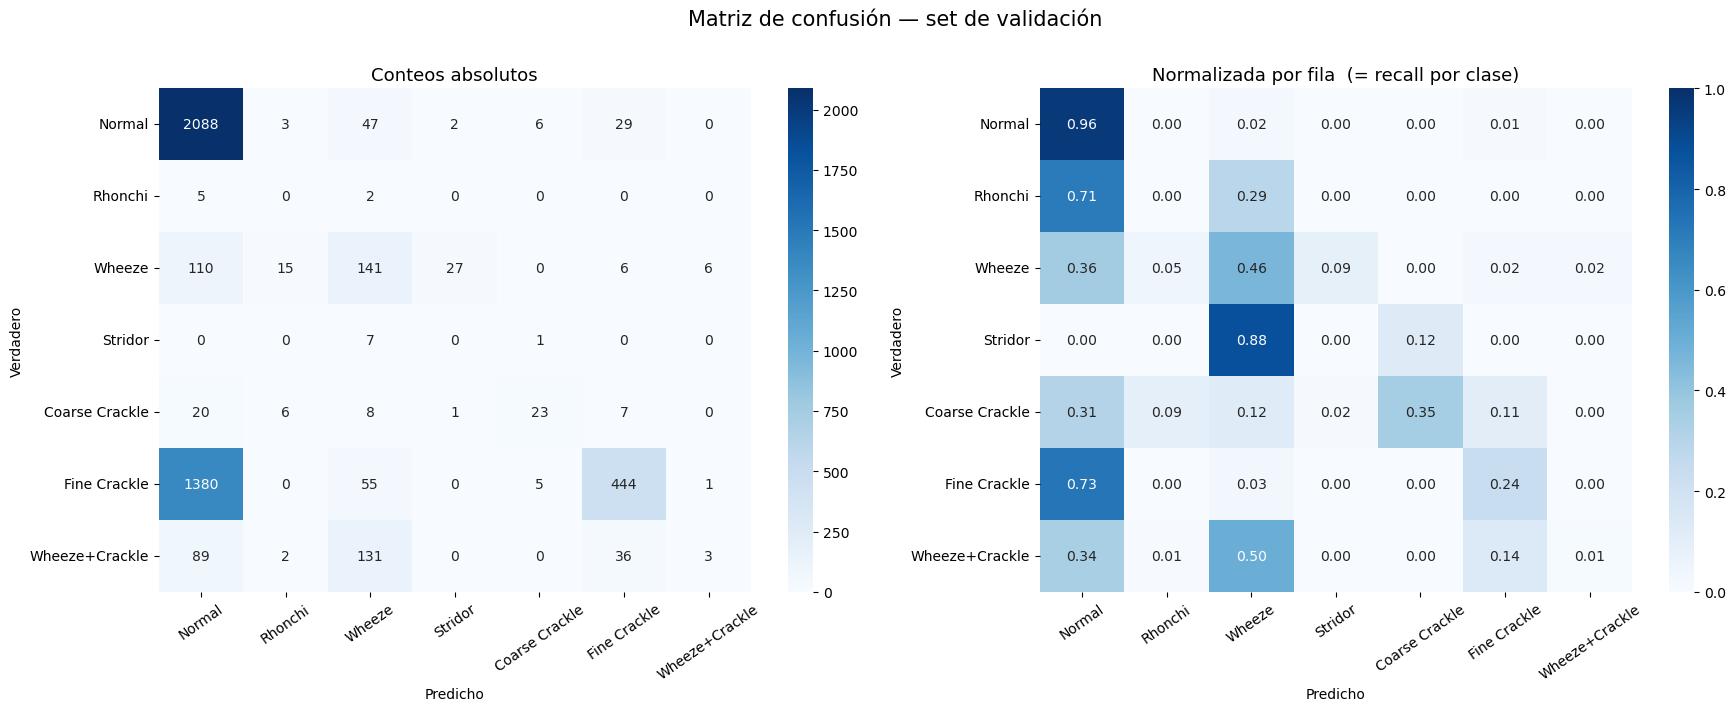

In [46]:
CLASS_NAMES = ["Normal", "Rhonchi", "Wheeze",
               "Stridor", "Coarse Crackle", "Fine Crackle", "Wheeze+Crackle"]

cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Izquierda: conteos absolutos
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0],
)
axes[0].set_title("Conteos absolutos", fontsize=13)
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Verdadero")
axes[0].tick_params(axis="x", rotation=35)

# Derecha: normalizada por fila (recall por clase)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm,
    annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[1],
)
axes[1].set_title("Normalizada por fila  (= recall por clase)", fontsize=13)
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Verdadero")
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle("Matriz de confusión — set de validación", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

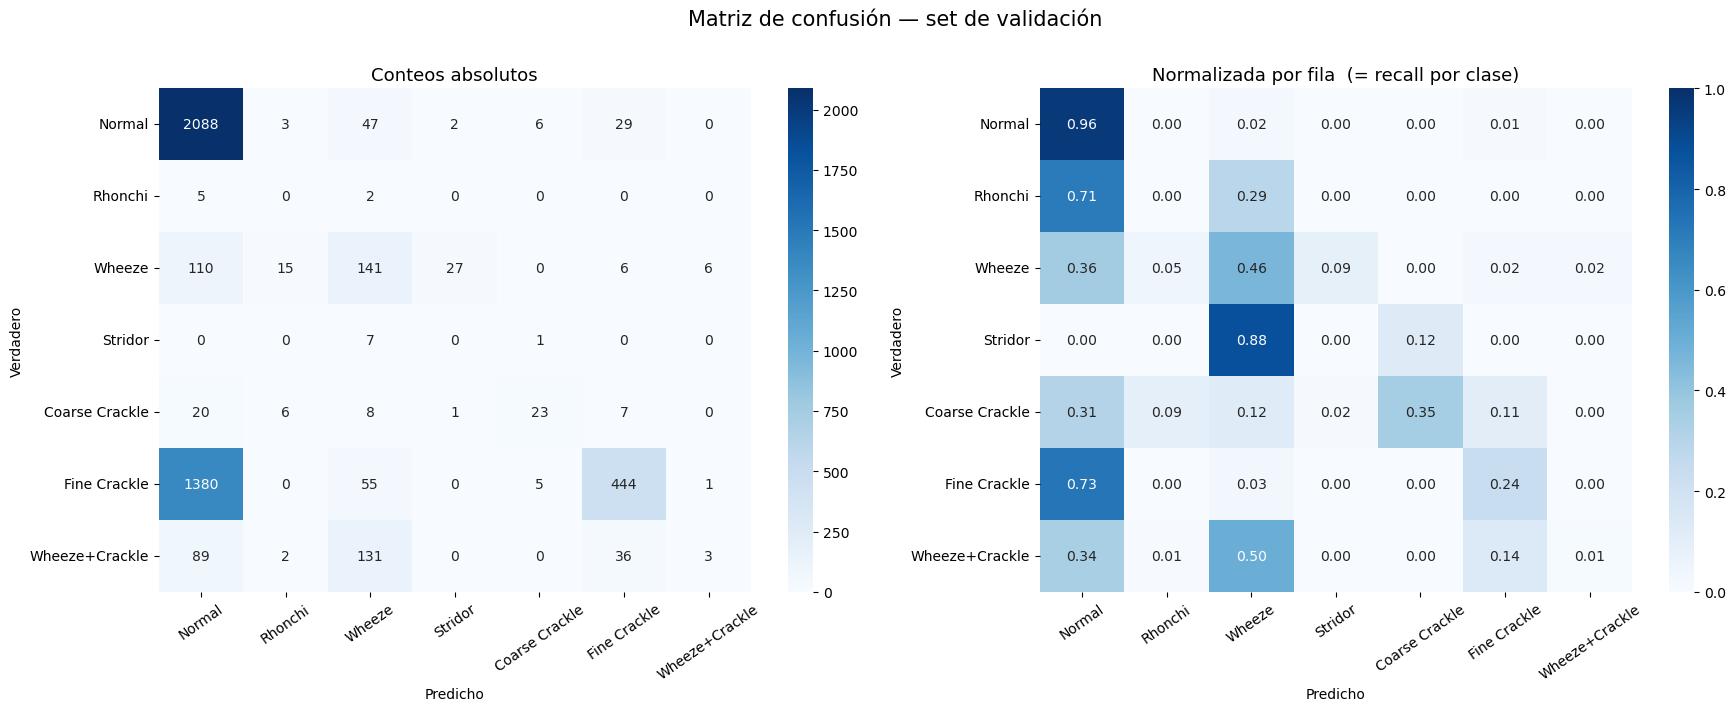

In [47]:
CLASS_NAMES = ["Normal", "Rhonchi", "Wheeze",
               "Stridor", "Coarse Crackle", "Fine Crackle", "Wheeze+Crackle"]

cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Izquierda: conteos absolutos
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0],
)
axes[0].set_title("Conteos absolutos", fontsize=13)
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Verdadero")
axes[0].tick_params(axis="x", rotation=35)

# Derecha: normalizada por fila (recall por clase)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm,
    annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[1],
)
axes[1].set_title("Normalizada por fila  (= recall por clase)", fontsize=13)
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Verdadero")
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle("Matriz de confusión — set de validación", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [48]:
# ── 5. Métricas por clase ────────────────────────────────────────────────
report = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=3,
    zero_division=0,
)
print(report)

                precision    recall  f1-score   support

        Normal      0.566     0.960     0.712      2175
       Rhonchi      0.000     0.000     0.000         7
        Wheeze      0.361     0.462     0.405       305
       Stridor      0.000     0.000     0.000         8
Coarse Crackle      0.657     0.354     0.460        65
  Fine Crackle      0.851     0.236     0.369      1885
Wheeze+Crackle      0.300     0.011     0.022       261

      accuracy                          0.574      4706
     macro avg      0.391     0.289     0.281      4706
  weighted avg      0.651     0.574     0.511      4706



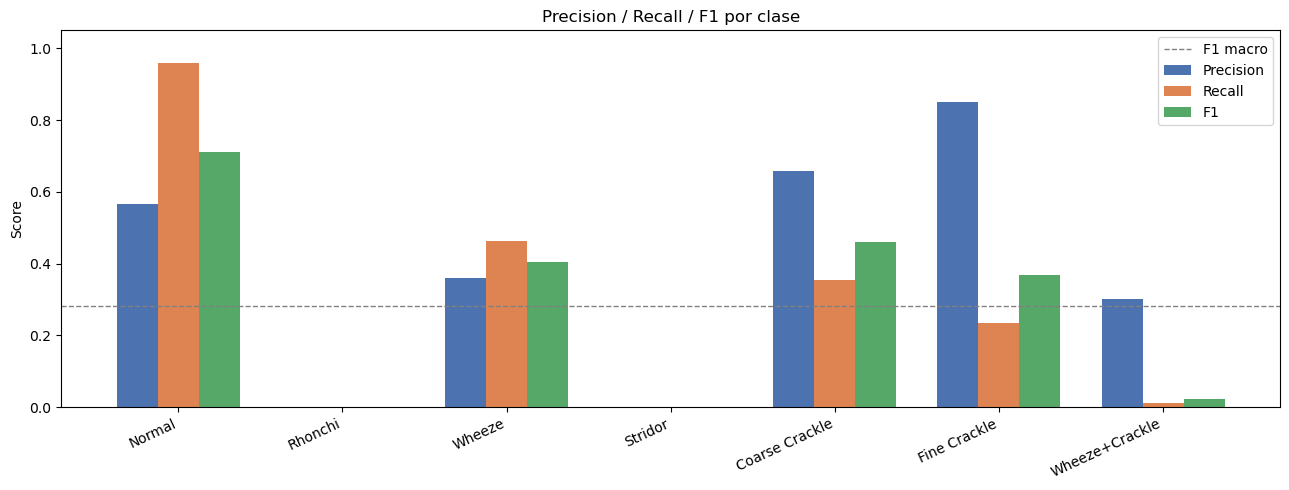

F1 macro    : 0.281
F1 weighted : 0.511


In [49]:
# ── 6. Resumen visual de F1 por clase ────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

f1        = f1_score(all_labels, all_preds, average=None, zero_division=0)
precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)

x       = np.arange(len(CLASS_NAMES))
width   = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, precision, width, label="Precision", color="#4C72B0")
ax.bar(x,         recall,    width, label="Recall",    color="#DD8452")
ax.bar(x + width, f1,        width, label="F1",        color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 por clase")
ax.axhline(y=f1_score(all_labels, all_preds, average="macro"), 
           color="gray", linestyle="--", linewidth=1, label="F1 macro")
ax.legend()
plt.tight_layout()
plt.show()

print(f"F1 macro    : {f1_score(all_labels, all_preds, average='macro'):.3f}")
print(f"F1 weighted : {f1_score(all_labels, all_preds, average='weighted'):.3f}")